<a href="https://colab.research.google.com/github/OrastaRakhmatullayeva/ML-projects/blob/main/XGBoost_Early_Stopping_va_Feature_Importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Topshiriq 1. Nega kerak?
n_estimators=1000 va early_stopping_rounds ishlatilmagan modelni tasavvur qiling. Bunday modelda qanday ikkita muammo yuzaga kelishi mumkin? Kamida bittasi overfitting bilan bog'liq bo'lmagan javob toping.


Answer:
n_estimators juda katta qiymat va bunga biz chegara esrly_stooping_rounds ni bermasak, model 1000 ta tree ning barchasini quradi.

hamda early_stopping_rounds ning default qiymati yo'qligi sababli.

MAIN reason: cost o'ta qimmat bo'ladi, yani without stopping building 1000 trees may requires more CPU/GPU, memory, time and others.


so we should consider and give them

Topshiriq 2. eval_set nima uchun kerak?
Early stopping ishlashi uchun nega alohida validatsiya to'plami (eval_set) kerak? Nega uni train to'plamining o'zi bilan almashtirib bo'lmaydi?


eval_set alohida validation to'plamidan iborat bo'lishi kk, chunki early stopping modelning yangi va ko'rilmagan qismidagi malumotlardan foydalanib, modelni baholaydi.

X_train eval_setda ishlatilishi mumkin ammo bu nega kk? chunki model albatta traindagi malumotlarni o'rganib, yodlab olib, doimiy kamayadi va earlly stoppingni sozlagan bo'lssakda u doimiy kamayib turganligi tufayli oxirigacha to'xtamaydi.



Topshiriq 3.

 “Sabr” tushunchasi
early_stopping_rounds=10 va early_stopping_rounds=100 orasidagi farqni tushuntiring. Qaysi holatda model “sabrsiz”, qaysi holatda “ha'dosli” bo'ladi? Har biri qanday xatoga olib kelishi mumkin?


albatta patience li model bu early_stopping_rounds=100, u ancha kuta oladi va optimal yondasha oladi.

aksincha esa early_stopping_rounds=10 bu impatience model, ammo bu har doim ham good emas, chunki bazi bir modellar 10 stepda yaxshilanmasdan yaxxshilanmasdan, keyin yaxshilanishi mumkin.


Topshiriq 4.

 Metrikaning roli
Agar eval_metric='logloss' bo'lsa-yu, siz aslida F1-score bo'yicha eng yaxshi modelni xohlasangiz, nima muammo bo'lishi mumkin? (Aynan shu datasetdagi disbalansni eslang.)


Disbalansli datasetda Logloss ko'pchilikni tashkil etuvchi sinfni to'g'ri topishga urg'u beradi, natijada model deyarli barcha ob'yektlarni ko'pchilik sinfga tegishli deb bashorat qilib, Logloss bo'yicha yaxhi ko'rsatkich berishi mumkin. Ammo bunday holatda kamchilik (pastroq uchrashuvchi) sinf e'tiborsiz qolib, Recall va natijada F1-score keskin tushib ketadi. Shuningdek, Early Stopping modelni F1-score pik darajaga chiqqan nuqtada emas, balki Logloss minimal bo'lgan noto'g'ri bosqichda to'xtatib qo'yadi.

AMALIY TASKS

Topshiriq 5. Asosiy ishga tushirish
Quyidagi bosqichlarni bajaruvchi kod yozing:

Datasetni train/validation/test'ga (masalan, 60/20/20) bo'ling.

XGBClassifier'ni n_estimators=1000, eval_set=[(X_val, y_val)] va early_stopping_rounds=20 bilan o'qiting.

model.best_iteration va model.best_score qiymatlarini chop eting.

Test to'plamida yakuniy F1-score va ROC-AUC'ni hisoblang.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_curve
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [2]:
df=pd.read_csv("/content/online_shoppers_intention.csv")



In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df=df.drop_duplicates()

In [6]:

(df['Revenue'].value_counts())/len(df['Revenue'])*100


,count
Revenue,
False,84.367063
True,15.632937


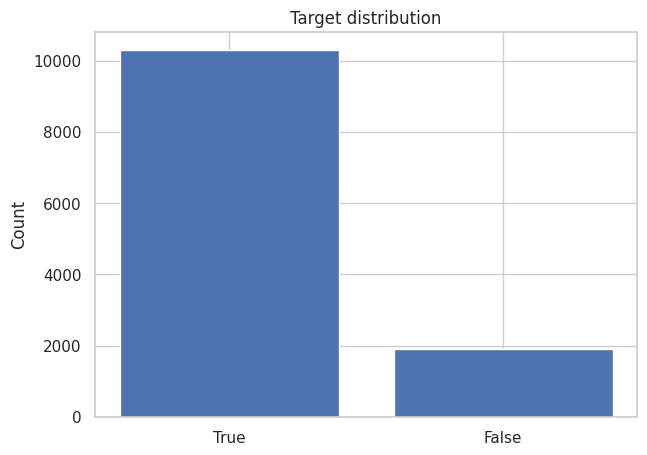

In [7]:

target_counts = df['Revenue'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["True", "False"], target_counts.values)
plt.title("Target distribution")
plt.ylabel("Count")
plt.show()

In [9]:
y = df["Revenue"].astype(int)
X = df.drop(columns=["Revenue"])

def build_processor(df_X):
    obj_cols = df_X.select_dtypes(include="object").columns
    num_cols = df_X.select_dtypes(include="number").columns

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    obj_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    processor = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("obj", obj_pipe, obj_cols),
    ])

    return processor, list(num_cols), list(obj_cols)


processor, num_cols, obj_cols = build_processor(X)
print("Numeric cols:", len(num_cols), ", Object cols:", len(obj_cols))


Numeric cols: 14 , Object cols: 2


In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)


In [11]:
X_train_pr = processor.fit_transform(X_train)
X_val_pr = processor.transform(X_val)
X_test_pr = processor.transform(X_test)


In [13]:
model = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    # scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric=["logloss", "auc"],
    early_stopping_rounds=30,
    random_state=RANDOM_STATE,
    tree_method="hist",
)

model.fit(
    X_train_pr, y_train,
    eval_set=[(X_train_pr, y_train), (X_val_pr, y_val)],
    verbose=False,
)

print("\nbest_iteration:", model.best_iteration)
print("best_score:", model.best_score)


best_iteration: 109
best_score: 0.926875493718625


In [17]:
pred=model.predict(X_test_pr)
proba=model.predict_proba(X_test_pr)[:,1]

print("Accuracy:",round(accuracy_score(y_test,pred),4))

print("F1-score:",round(f1_score(y_test,pred),4))
print("ROC-AUC score:",round(roc_auc_score(y_test,pred),4))
# print("PR-AUC:",round(average_precision_score(y_test,pred),4))

Accuracy: 0.9066
F1-score: 0.6657
ROC-AUC score: 0.7794


In [23]:
import time

iterations = [5, 10, 20, 50, 100]
results = []

for i in iterations:
    model = XGBClassifier(
        n_estimators=1000,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric=["logloss", "auc"],
        early_stopping_rounds=i,
        random_state=RANDOM_STATE,
        tree_method="hist",
    )

    start = time.time()
    model.fit(
        X_train_pr, y_train,
        eval_set=[(X_train_pr, y_train), (X_val_pr, y_val)],
        verbose=False,
    )
    elapsed = time.time() - start

    pred = model.predict(X_test_pr)
    f1 = f1_score(y_test, pred)

    results.append({
        "early_stopping_rounds": i,
        "best_iteration": model.best_iteration,
        "test_f1": round(f1, 4),
        "train_time_sec": round(elapsed, 3),
    })

results_df = pd.DataFrame(results)
print(results_df)

   early_stopping_rounds  best_iteration  test_f1  train_time_sec
0                      5              19   0.4737           0.285
1                     10              62   0.6676           1.190
2                     20             109   0.6657           0.863
3                     50             109   0.6657           1.294
4                    100             109   0.6657           3.969


# 3-blok — Xatoni toping (debugging)

In [26]:
import xgboost as xgb
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = xgb.XGBClassifier(
    n_estimators=500,
    eval_metric="logloss",
    early_stopping_rounds=10
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

preds = model.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, preds))


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Month: object, VisitorType: object

birinchi error: datani 3 ga emas 2 ga bo'lish, validation part yo'q

2-error : eval_set da test part berilgan, aslida validation part bo'lishi kk edi.

Tasks 8,9 and 10:

In [32]:
import time


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

processor, num_cols, obj_cols = build_processor(X)
X_train_pr = processor.fit_transform(X_train)
X_val_pr = processor.transform(X_val)
X_test_pr = processor.transform(X_test)

feature_names = processor.get_feature_names_out()
X_train_pr = pd.DataFrame(X_train_pr, columns=feature_names, index=X_train.index)
X_val_pr = pd.DataFrame(X_val_pr, columns=feature_names, index=X_val.index)
X_test_pr = pd.DataFrame(X_test_pr, columns=feature_names, index=X_test.index)

assert X_train_pr.shape[0] == y_train.shape[0], \
    f"Mismatch! X_train_pr: {X_train_pr.shape[0]}, y_train: {y_train.shape[0]}"
assert X_val_pr.shape[0] == y_val.shape[0], \
    f"Mismatch! X_val_pr: {X_val_pr.shape[0]}, y_val: {y_val.shape[0]}"

print("X_train_pr:", X_train_pr.shape, " y_train:", y_train.shape)
print("X_val_pr:  ", X_val_pr.shape,   " y_val:  ", y_val.shape)


results_ab = []

model_a = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,

    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    tree_method="hist",
)

start = time.time()
model_a.fit(X_train_pr, y_train, eval_set=[(X_val_pr, y_val)], verbose=False)
time_a = time.time() - start

pred_a = model_a.predict(X_test_pr)
proba_a = model_a.predict_proba(X_test_pr)[:, 1]

results_ab.append({
    "model": "A (no early stopping)",
    "trees_used": model_a.n_estimators,
    "train_time_sec": round(time_a, 3),
    "test_f1": round(f1_score(y_test, pred_a), 4),
    "test_roc_auc": round(roc_auc_score(y_test, proba_a), 4),
})

print(pd.DataFrame(results_ab))

X_train_pr: (7323, 27)  y_train: (7323,)
X_val_pr:   (2441, 27)  y_val:   (2441,)
                   model  trees_used  train_time_sec  test_f1  test_roc_auc
0  A (no early stopping)        1000          13.628   0.6379        0.9264


This project applies XGBoost to the Online Shoppers Purchasing Intention dataset (12,330 sessions, ~15.5% resulting in a purchase) to predict purchase intent. To handle the class imbalance, scale_pos_weight was used instead of resampling, and the model was trained with early stopping (early_stopping_rounds=30) on a held-out validation set, converging in just a few boosting rounds. On the untouched test set, the model reached an F1-score of 0.62, ROC-AUC of 0.93, and PR-AUC of 0.70 — strong discriminative power despite the imbalance.